In [8]:
import pandas as pd
from sklearn.datasets import load_breast_cancer

# 1. 데이터셋 로드
data = load_breast_cancer()

# 2. 독립변수(Feature) 데이터를 데이터프레임으로 변환
# data.data: 실제 수치 데이터, data.feature_names: 컬럼 이름
df = pd.DataFrame(data.data, columns=data.feature_names)

# 3. 종속변수(Target) 컬럼 추가
# 0: 악성(Malignant), 1: 양성(Benign)
df['target'] = data.target

# 4. 상위 5개 행 확인
print(df.head())

# (참고) 데이터프레임 정보 확인
# df.info()

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 1. 독립변수(X)와 종속변수(y) 설정
X = df.drop('target', axis=1)  # target 열을 제외한 모든 데이터를 X로 사용
y = df['target']               # target 열만 y로 사용

# 2. 학습용(Train)과 테스트용(Test) 데이터 분리 (8:2 비율)
# random_state는 결과를 고정하기 위한 시드값입니다.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. 데이터 스케일링 (중요!)
# 변수마다 단위(예: 면적은 1000단위, 매끄러움은 0.1단위)가 다르므로 단위를 맞춰줍니다.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. 로지스틱 회귀 모델 생성 및 학습
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# 5. 예측 및 결과 평가
y_pred = model.predict(X_test_scaled)

print(f"정확도(Accuracy): {accuracy_score(y_test, y_pred):.4f}")
print("\n분류 보고서:")
print(classification_report(y_test, y_pred))
print(f"정확도가 높다고 나옴")

정확도(Accuracy): 0.9737

분류 보고서:
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

정확도가 높다고 나옴


C:\Users\itwill\AppData\Local\Temp\ipykernel_12740\2228236709.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette=colors)


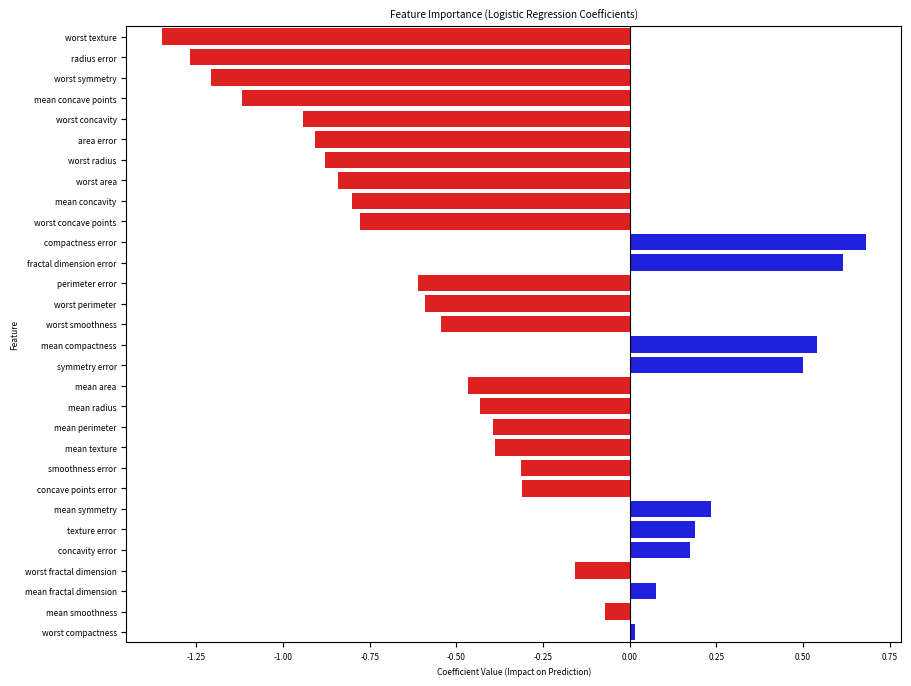

wort texture, worst concave points, worst radius 가 가장 상위 랭크
세포의 질감이 거칠거나 오목한 점이 많거나 크기가 클수록 모델은 이를 강력한 암의 신호로 받아들임
정상세포의 특징
texterror 같은 변수가 양수로 나올 수 있음.
결론적으로 이 모델은 단순히 크기만 보는  것이 아니라, 세포의 모양(오목한 정도)과 질감을 암 판별의 매우 중요한 근거로 삼고 있다는 것을 알 수 있음


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. 변수명과 회귀계수를 매칭하여 데이터프레임 생성
# model.coef_[0]에 각 변수의 가중치(계수)가 들어있습니다.
coef_df = pd.DataFrame({
    'Feature': data.feature_names,
    'Coefficient': model.coef_[0]
})

# 2. 계수의 절댓값을 기준으로 내림차순 정렬 (영향력이 큰 순서대로 보기 위함)
# 절댓값이 클수록 모델의 결정에 큰 영향을 미칩니다.
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='Abs_Coefficient', ascending=False)

# 3. 시각화
plt.figure(figsize=(10, 8))
# 양수는 파란색(양성/안전), 음수는 빨간색(악성/위험)으로 표현
colors = ['blue' if c > 0 else 'red' for c in coef_df['Coefficient']]
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette=colors)

plt.title('Feature Importance (Logistic Regression Coefficients)')
plt.xlabel('Coefficient Value (Impact on Prediction)')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8) # 0 기준선
plt.show()
print(f"wort texture, worst concave points, worst radius 가 가장 상위 랭크\n세포의 질감이 거칠거나 오목한 점이 많거나 크기가 클수록 모델은 이를 강력한 암의 신호로 받아들임")
print(f"정상세포의 특징\ntexterror 같은 변수가 양수로 나올 수 있음.\n결론적으로 이 모델은 단순히 크기만 보는  것이 아니라, 세포의 모양(오목한 정도)과 질감을 암 판별의 매우 중요한 근거로 삼고 있다는 것을 알 수 있음")

ROC Curve 시각화 및 AUC 계산 코드

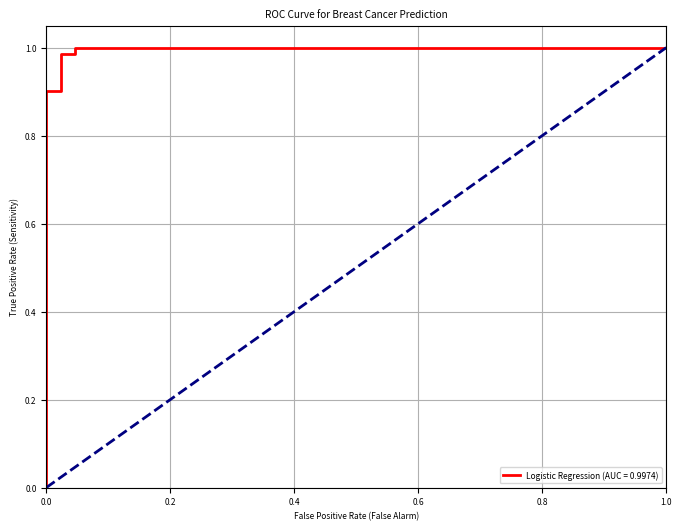

최종 성적(AUC Score): 0.9974


In [18]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# 1. 예측 '확률' 가져오기
# predict()는 0, 1 정수만 나오지만, ROC를 그리려면 확률(0.75, 0.92 등)이 필요합니다.
# [:, 1]은 '클래스 1(양성, Benign)'일 확률만 가져오는 슬라이싱입니다.
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

# 2. ROC Curve 데이터 계산 (FPR, TPR, 임계값)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# 3. AUC (곡선 아래 면적) 점수 계산
roc_auc = roc_auc_score(y_test, y_pred_proba)

# 4. 그래프 그리기
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='red', lw=2, label=f'Logistic Regression (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # 랜덤 추측선 (50점 기준)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (False Alarm)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve for Breast Cancer Prediction')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print(f"최종 성적(AUC Score): {roc_auc:.4f}")